# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] numpy==1.25.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 81.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


### Import necessary packages

In [2]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [5]:
# Connect google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Path to  .npy file
safeguard_img_paths = '/content/drive/MyDrive/content/drive/CNN/images_proj.npy'
# Load image data
safeguard_images= np.load(safeguard_img_paths)


In [7]:
# Load label csv file data
safeguard_img_labels=pd.read_csv('/content/drive/MyDrive/content/drive/CNN/Labels_proj.csv')

# **Exploratory Data Analysis**

### Checking the label dataset

In [8]:
safeguard_img_labels.shape

(631, 1)

* There are 631 label samples

### Checking the image dataset

In [9]:
safeguard_images.shape

(631, 200, 200, 3)

* There are 631 sample images of size(200x200) with 3 color channels

### Check the size of an image

(200, 200, 3)

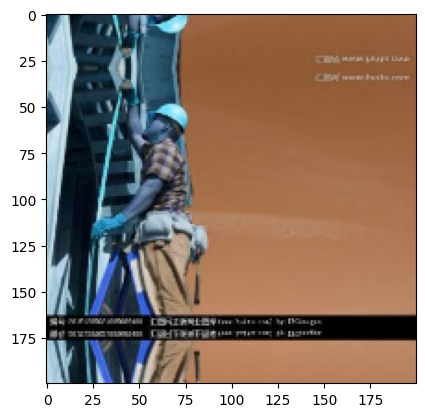

In [10]:
# Display an image and shape
plt.imshow(safeguard_images[2])
safeguard_images[2].shape


* Each image is of size (200x200) with 3 channels

###Plot random images from each of the classes and print their corresponding labels.

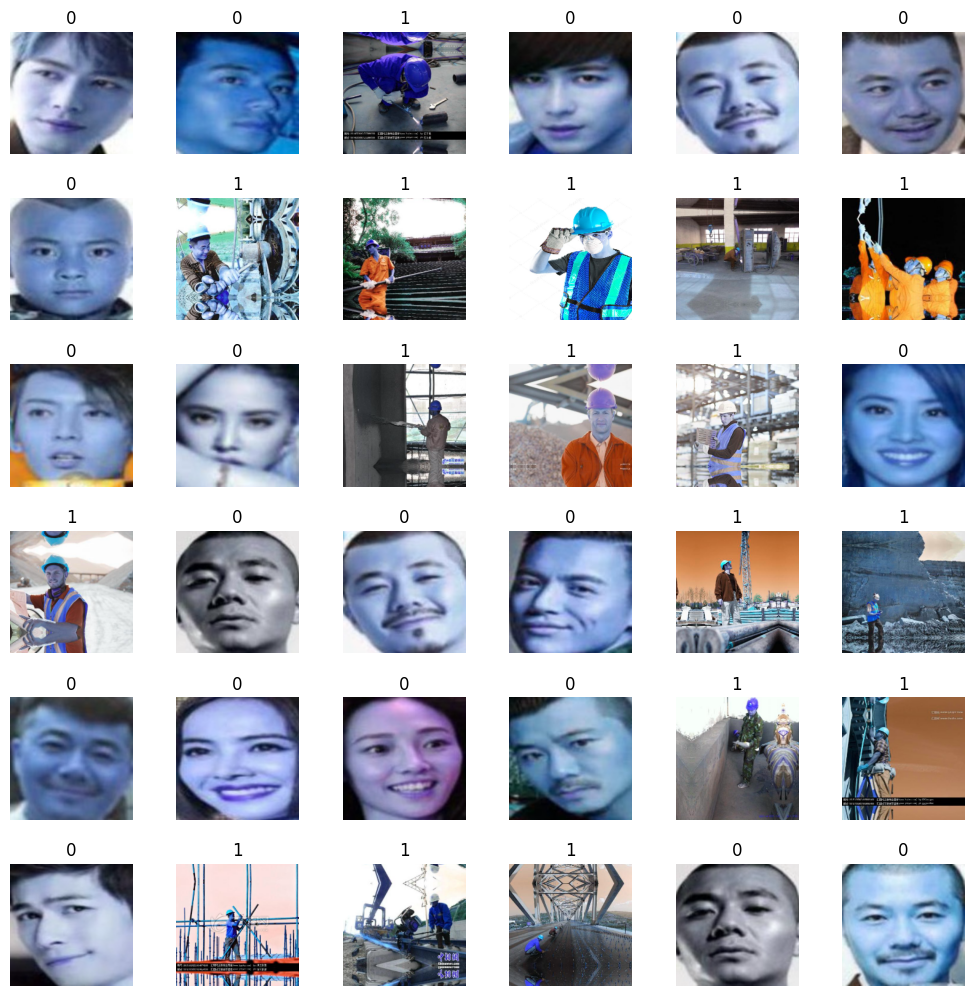

In [11]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n,p,q = safeguard_images.shape

fig, axes = plt.subplots(6,6, figsize=(10,10))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)


    # Display the image
    ax.imshow(safeguard_images[random_index], cmap='gray')

    # Display the label above the image
    ax.set_title(safeguard_img_labels.iloc[random_index,0])
    ax.set_axis_off()

### Checking for Null values

In [12]:
safeguard_img_labels.isnull().sum()

,0
Label,0


* There aro no null values

## Checking for class imbalance


#### Plot the Class Distribution


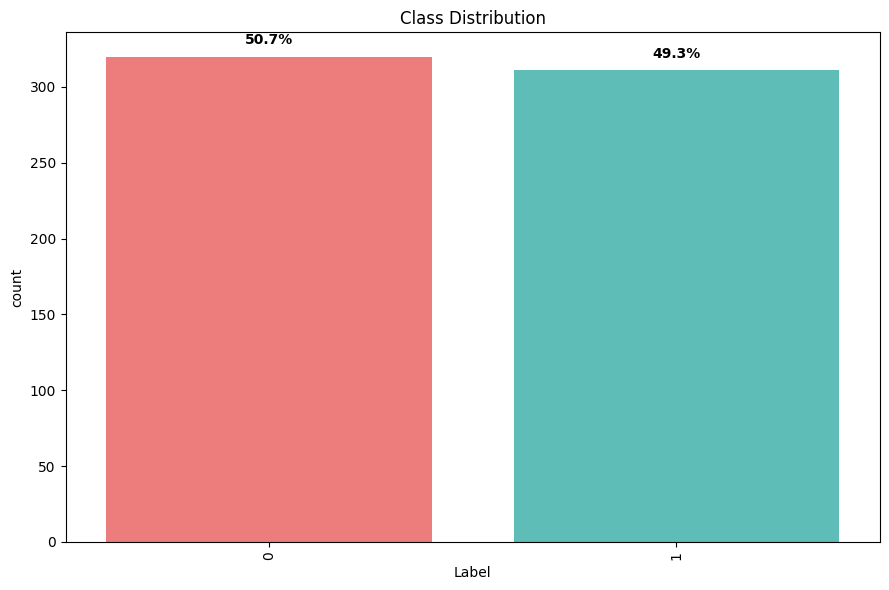

Label
0    320
1    311
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the label counts
counts = safeguard_img_labels['Label'].value_counts()
total = len(safeguard_img_labels)

# Define two distinct colors (you can customize these)
colors = ['#FF6B6B', '#4ECDC4']  # Example: coral and teal

# Create the plot
plt.figure(figsize=(9, 6))
ax = sns.countplot(
    data=safeguard_img_labels,
    x='Label',
    order=counts.index,
    palette=colors  # Apply custom colors
)
plt.xticks(rotation='vertical')
plt.title("Class Distribution")

# Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue
    percentage = 100 * height / total
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height + total * 0.01,
        f'{percentage:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
        weight='bold'
    )

plt.tight_layout()
plt.show()

# Print counts
print(counts)

* There are two class labels 0 and 1; 0 for Without Helmet and 1 for With Helmet
* There is are no significant imbalances in the class distribution as Class 0 has 50.7% and Class 1 has 49.3% of labels

# **Data Preprocessing for CNN Models**

The original image is 200 x 200 pixels in size and has three channels. We preprocess the image data so that model execution consumes less memory and CPU. To achieve this, we convert each image to greyscale, reducing it to one channel, and reshape it to 64x64. We then convert each image channel to three to adapt to the input shapes of the CNN and VGG 16 models.

## Reshaping and Converting images to grayscale

In [14]:

# Preprocessing: Grayscale + Resize + Add Channel + Normalize
images_gray = []

height, width = 64, 64
dimensions = (width, height)

for i in range(len(safeguard_images)):
    # Convert to grayscale
    gray = cv2.cvtColor(safeguard_images[i], cv2.COLOR_RGB2GRAY)

    # Resize gray scale images
    resized_gray = cv2.resize(gray, dimensions, interpolation=cv2.INTER_LINEAR)

    images_gray.append(resized_gray)


# Convert to numpy array
images_gray = np.array(images_gray)  # (N, 64, 64)


# Add channel dimension
images_gray = images_gray[..., np.newaxis]  # (N, 64, 64, 1)

# Convert from (N, 64, 64, 1) to (N, 64, 64, 3)
images_rgb_gray = np.repeat(images_gray, 3, axis=-1)


print("Final shape gray image:", images_rgb_gray.shape)  # Should be (N, 64, 64, 1)


Final shape gray image: (631, 64, 64, 3)


* Each image is now shape of (64,64,3)

###Plot random images from each of the classes and print their corresponding labels.

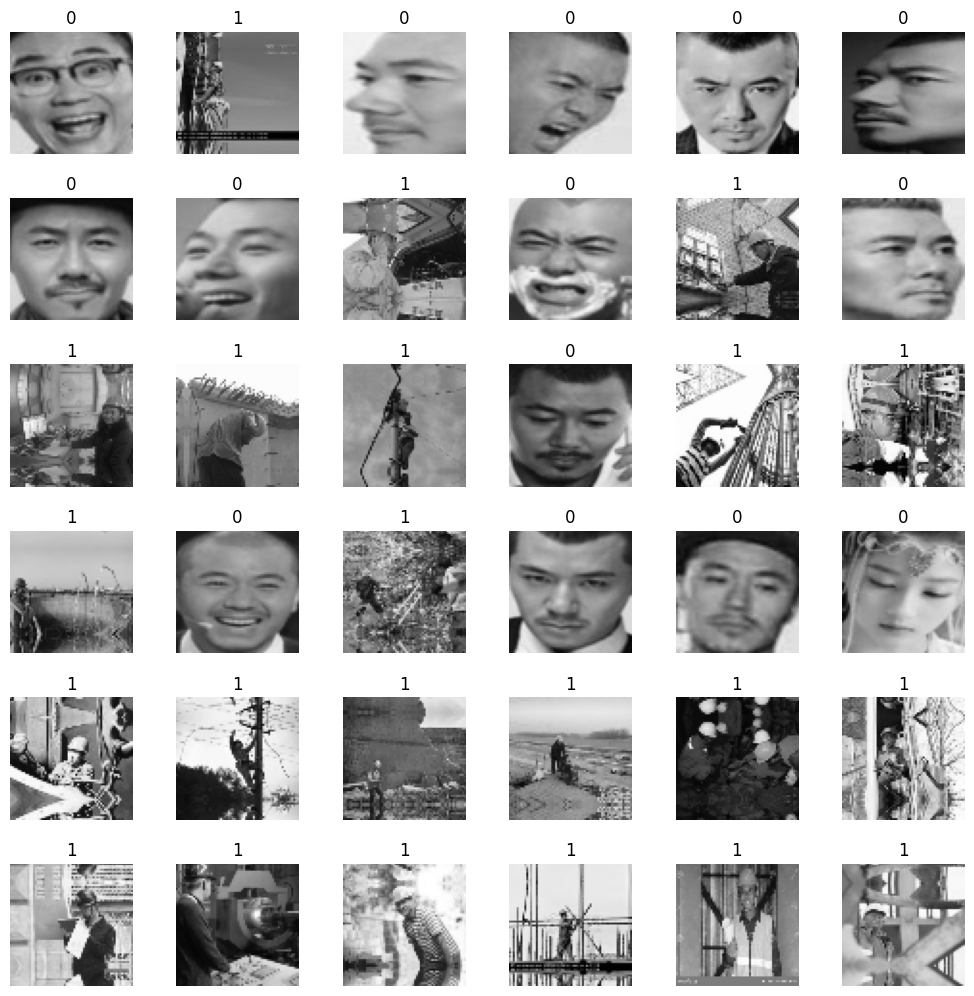

In [15]:
# Plot the images
m = len(images_gray)

fig, axes = plt.subplots(6,6, figsize=(10,10))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # Display the image
    ax.imshow(images_rgb_gray[random_index], cmap='gray')

    # Display the label above the image
    ax.set_title(safeguard_img_labels.iloc[random_index,0])
    ax.set_axis_off()

* All the images are now gray scale and have size (64x64)




### Splitting the grayscale dataset



- As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
- We use `train_test_split()` function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images_rgb_gray),safeguard_img_labels , test_size=0.2, random_state=42,stratify=safeguard_img_labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [17]:
# Display the split distribution
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(504, 64, 64, 3) (504, 1)
(63, 64, 64, 3) (63, 1)
(64, 64, 64, 3) (64, 1)


### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling down** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [18]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

## Utility Functions For Model Evaluation

In [19]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [20]:
# Define a function to plot the confusion matrix
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

We  will try different **CNN models** further on the image data to see which model gives a good performance based on the metrics such as **Accuracy, Precison, Recall and F1 Score**.
We will build  **four models**; **a simple CNN model** and apply transfer learning on existing model **VGG16**.


##Model 1: Simple Convolutional Neural Network (CNN)

* Let's start with a simple CNN model neural network consisting of:
  * **Input Layer**: Accepts images of size `64×64` with 3 color channels (RGB), so input shape is `(64, 64, 3)`.
  * **Convolutional Block 1**:
    - Conv2D layer with **64 filters**, kernel size `(3,3)`, ReLU activation, and `'same'` padding.
    - MaxPooling2D layer with pool size `(2,2)` to downsample spatial dimensions.
    - BatchNormalization layer to stabilize and accelerate training.
  * **Convolutional Block 2**:
    - Conv2D layer with **32 filters**, kernel size `(3,3)`, ReLU activation, and `'same'` padding.
    - MaxPooling2D layer with pool size `(2,2)`.
    - BatchNormalization layer.
  * **Convolutional Block 3**:
    - Conv2D layer with **32 filters**, kernel size `(3,3)`, ReLU activation, and `'same'` padding.
    - MaxPooling2D layer with pool size `(2,2)`.
  * **Convolutional Block 4**:
    - Conv2D layer with **16 filters**, kernel size `(3,3)`, ReLU activation, and `'same'` padding.
    - No pooling after this layer — prepares for flattening.
  * **Flatten Layer**: Converts 2D feature maps into a 1D vector for the dense layers.
  * **Fully Connected (Dense) Layers**:
    - Dense layer with **64 neurons**, ReLU activation.
    - Dropout layer with **25%** dropout rate to prevent overfitting.
    - Dense layer with **32 neurons**, ReLU activation.
    - Another Dropout layer with **25%** dropout rate.
    - Dense layer with **32 neurons**, ReLU activation.
  * **Output Layer**:
    - Dense layer with **1 neuron**, using **sigmoid** activation — suitable for binary classification.

  * **Loss Function** : Binary CrossEntropy
  * **Optimizer** : Adam
  * **Batch Size** : Default
  * **Epoch** : 20

In [21]:
# Create model structure
cnn_model = Sequential()
# Convolution Block 1
cnn_model.add(Conv2D(64, (3,3), activation='relu', input_shape=(64, 64, 3), padding = 'same'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(BatchNormalization())
# Convolution Block 2
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding = 'same'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(BatchNormalization())
# Convolution Block 3
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding = 'same'))
cnn_model.add(MaxPooling2D(2,2))
# Convolution Block 4
cnn_model.add(Conv2D(16, (3,3), activation='relu', padding = 'same'))
# Flatten Layer
cnn_model.add(Flatten())
# Fully Connected Layers
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(32, activation='relu'))
# Output Layer
cnn_model.add(Dense(1, activation='sigmoid'))

In [22]:
cnn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics = ['accuracy'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,281 (403.44 KB)

 Trainable params: 103,089 (402.69 KB)

 Non-trainable params: 192 (768.00 B)

In [23]:
model_history = cnn_model.fit(X_train_normalized,y_train,
                              validation_data=(X_val_normalized, y_val),
                              epochs=20)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 718ms/step - accuracy: 0.6087 - loss: 0.6597 - val_accuracy: 0.7143 - val_loss: 0.6407
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9286 - loss: 0.1925 - val_accuracy: 0.5079 - val_loss: 0.7793
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9435 - loss: 0.2211 - val_accuracy: 0.5079 - val_loss: 0.7619
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9484 - loss: 0.1390 - val_accuracy: 0.5079 - val_loss: 0.7047
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9510 - loss: 0.1927 - val_accuracy: 0.5079 - val_loss: 0.7716
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9826 - loss: 0.0489 - val_accuracy: 0.5079 - val_loss: 1.2823
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9775 - loss: 0.0654 - val_accuracy: 0.5079 - val_loss: 1.1030
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9961 - loss: 0.0183 - val_accuracy: 0.5079 -

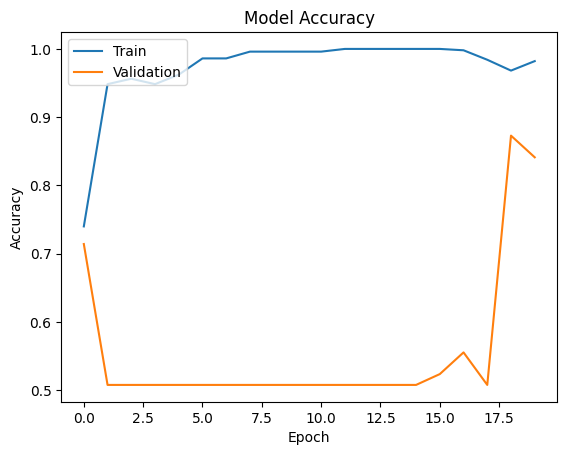

In [24]:
# Plot the Train and Validation Accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [25]:
model_1_train_perf = model_performance_classification(cnn_model, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.847222  0.847222   0.882549   0.84317


In [26]:
cnn_model.predict(X_val_normalized[1].reshape(1,64,64,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step


array([[0.8936541]], dtype=float32)

### Plotting Confusion Matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


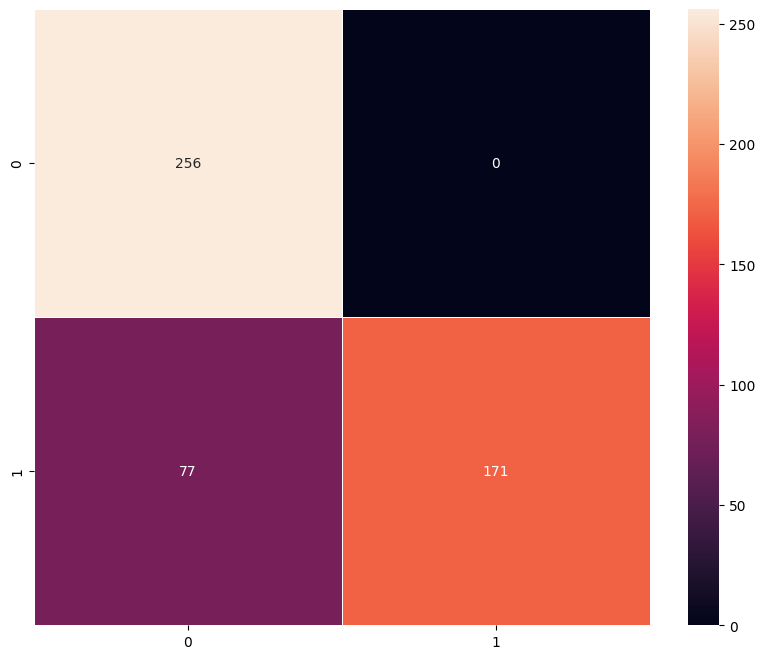

In [27]:
plot_confusion_matrix(cnn_model,X_train_normalized,y_train)

In [28]:
model_1_valid_perf = model_performance_classification(cnn_model, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
Validation performance metrics
   Accuracy   Recall  Precision  F1 Score
0   0.84127  0.84127   0.879063  0.836732


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


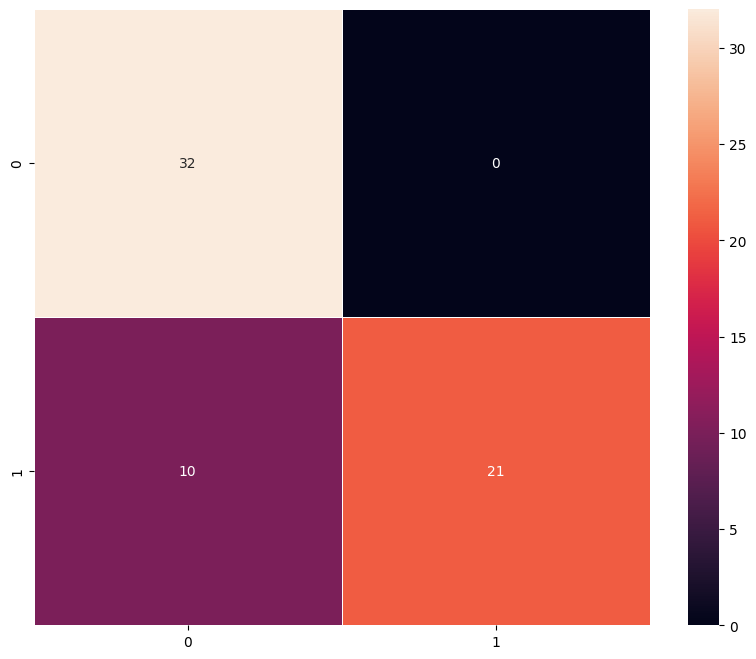

In [29]:
plot_confusion_matrix(cnn_model,X_val_normalized,y_val)

* The simple CNN Model has achieved **accuracy** of  ~84% on both training set and validation set.

### Vizualizing the predictions

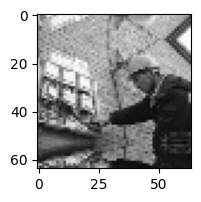

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Label :  With Helmet
True Label : With Helmet


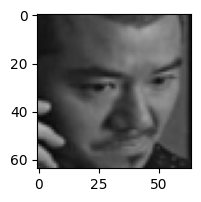

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


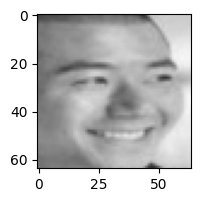

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


In [30]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_normalized[1])
plt.show()
pred=cnn_model.predict(X_val_normalized[1].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[1,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()

pred=cnn_model.predict(X_val_normalized[33].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[33,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)


plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()

pred=cnn_model.predict(X_val_normalized[36].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[36,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)



* The model prediction on randomly chosen images are same as the true labels

## Model 2: (VGG-16 (Base))

- We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

- For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer (output).
  * **Fully Connected (Dense) Layers**:
    - Dense layer with **25 neurons**, ReLU activation.
   
  * **Output Layer**:
    - Dense layer with **1 neuron**, using **sigmoid** activation — suitable for binary classification.

  * **Loss Function** : Binary Cross Entropy
  * **Optimizer** : Adam
  * **Batch Size** : 128
  * **Epoch** : 20


In [31]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(64,64,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [33]:
# Build Model
model_2= Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Add fully connected layers
model_2.add(Dense(25,activation='relu'))
# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [34]:
opt=Adam()
# Compile model
model_2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
# Generating the summary of the model
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │        51,225 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,765,939 (56.33 MB)

 Trainable params: 51,251 (200.20 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [36]:
train_datagen = ImageDataGenerator()

In [37]:
# Epochs
epochs = 20
# Batch size
batch_size = 128

history_vgg16 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.6532 - loss: 0.6520 - val_accuracy: 0.9841 - val_loss: 0.4031
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9922 - loss: 0.3892 - val_accuracy: 1.0000 - val_loss: 0.3163
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9869 - loss: 0.2829 - val_accuracy: 1.0000 - val_loss: 0.1527
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9844 - loss: 0.1499 - val_accuracy: 1.0000 - val_loss: 0.1207
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9934 - loss: 0.1072 - val_accuracy: 1.0000 - val_loss: 0.0608
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9844 - loss: 0.0764 - val_accuracy: 1.0000 - val_loss: 0.0501
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9927 - loss: 0.0578 - val_accuracy: 1.0000 - val_loss: 0.0329
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9922 - loss: 0.0359 - val_accuracy: 1.0000 - val_loss: 0.029

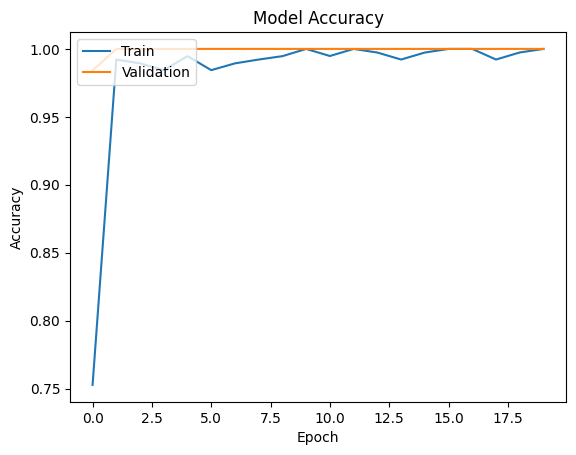

In [38]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [39]:
model_2_train_perf = model_performance_classification(model_2, X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.998016  0.998016   0.998024  0.998016


### Plotting Confusion Matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


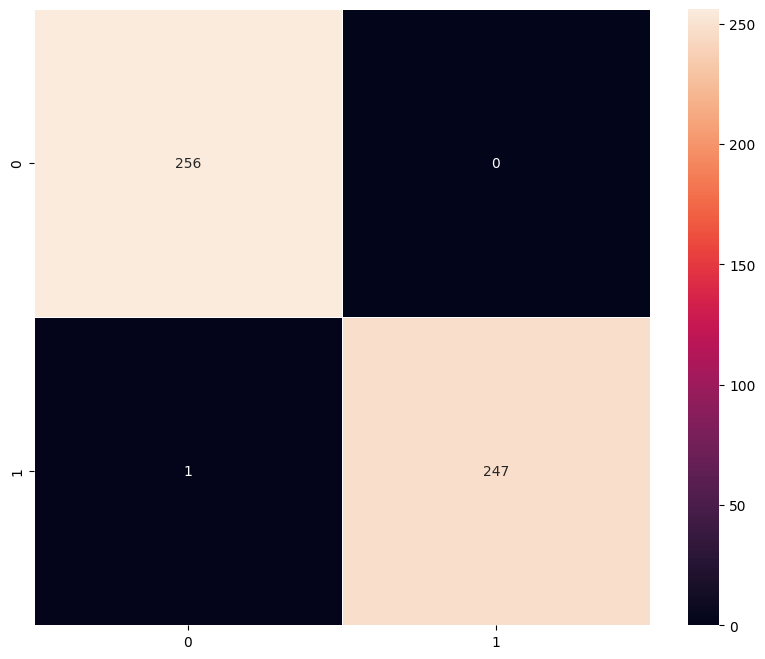

In [40]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [41]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


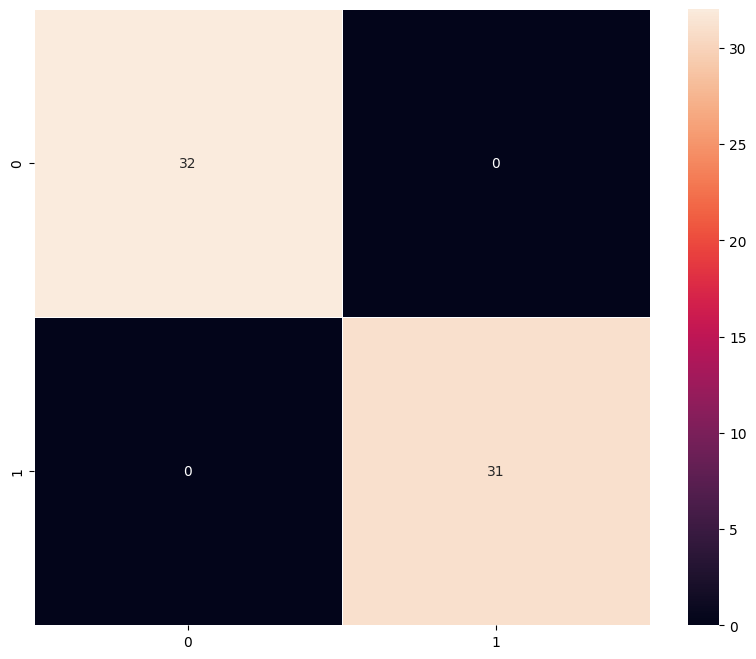

In [42]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

* The VGG16 Base Model achieves accuracy 99% on training set and 100% on validation data

### Vizualizing the predictions

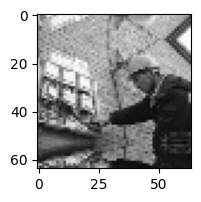

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 994ms/step
Predicted Label :  With Helmet
True Label : With Helmet


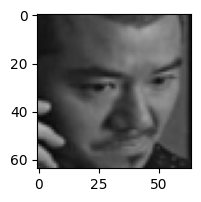

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


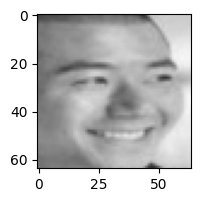

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


In [43]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_normalized[1])
plt.show()
pred=model_2.predict(X_val_normalized[1].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[1,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()

pred=model_2.predict(X_val_normalized[33].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[33,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)


plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()

pred=model_2.predict(X_val_normalized[36].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[36,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)



## Model 3: (VGG-16 (Base + FFNN))

* Let's build a transfer learning model based on VGG16, consisting of:
  * **Pre-trained VGG16 Backbone**: The base `vgg_model` (assumed to be the convolutional part of VGG16, with weights pre-trained on ImageNet and typically frozen) is added as the first layer to extract high-level visual features from input images.
  * **Flatten Layer**: Converts the 3D feature maps output by the VGG16 convolutional base into a 1D feature vector suitable for input into fully connected layers.
  * **Feed-Forward Neural Network (Custom Head)**:
    - Dense layer with **25 neurons** and **ReLU** activation.
    - Dropout layer with a **40%** dropout rate to reduce overfitting.
    - Dense layer with **10 neurons** and **ReLU** activation.
  * **Output Layer**:
    - Dense layer with **1 neuron** and **sigmoid** activation.
  * **Loss Function** : Binary Cross Entropy
  * **Optimizer** : Adam
  * **Batch Size** : 128
  * **Epoch** : 20




In [44]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(25,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(10,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [45]:
opt = Adam()

In [46]:
# Compile model
model_3.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [47]:
# Generating the summary of the model
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │        51,225 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,766,184 (56.33 MB)

 Trainable params: 51,496 (201.16 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [48]:
history_vgg16_ffnn = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4864 - loss: 0.8077 - val_accuracy: 0.6190 - val_loss: 0.5224
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5703 - loss: 0.5608 - val_accuracy: 0.6667 - val_loss: 0.4830
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5820 - loss: 0.5269 - val_accuracy: 0.8254 - val_loss: 0.4116
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6406 - loss: 0.4403 - val_accuracy: 0.8730 - val_loss: 0.3980
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6368 - loss: 0.4464 - val_accuracy: 0.8571 - val_loss: 0.3711
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6328 - loss: 0.4069 - val_accuracy: 0.8889 - val_loss: 0.3617
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6787 - loss: 0.3954 - val_accuracy: 0.9524 - val_loss: 0.3397
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7333 - loss: 0.3633 - val_accuracy: 0.9683 - val_loss: 0.3343

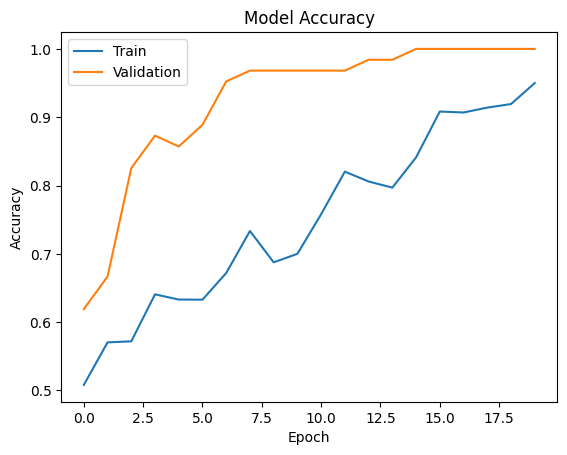

In [49]:
plt.plot(history_vgg16_ffnn.history['accuracy'])
plt.plot(history_vgg16_ffnn.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [50]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.996032  0.996032   0.996063  0.996031


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


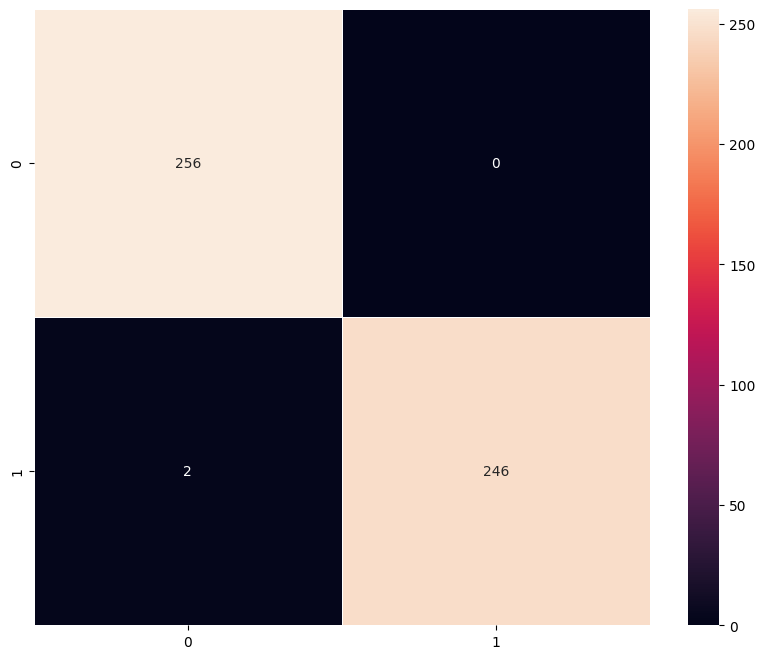

In [51]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [52]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


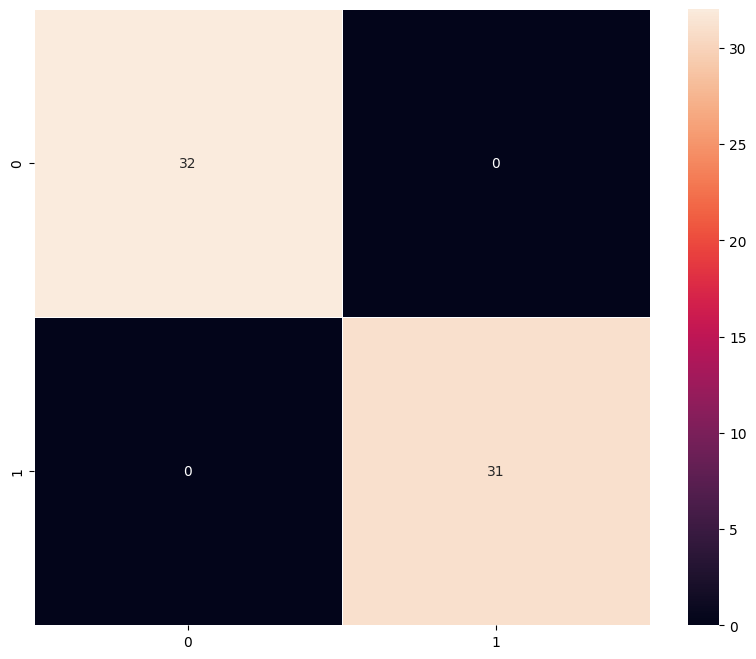

In [53]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

- The model has achieved approximately 99% accuracy on the training set and 100% accuracy on the validation set.

#### Visualizing the prediction:

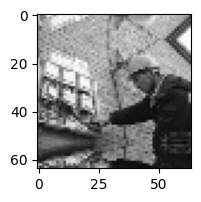

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
Predicted Label :  With Helmet
True Label : With Helmet


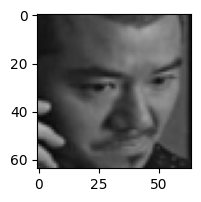

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


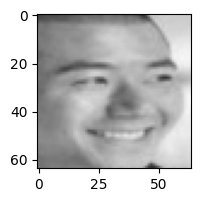

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


In [54]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_normalized[1])
plt.show()
pred=model_3.predict(X_val_normalized[1].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[1,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()

pred=model_3.predict(X_val_normalized[33].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[33,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)


plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()

pred=model_3.predict(X_val_normalized[36].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[36,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)



## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc

- We will build the model with the following configuration
  * **Feed-Forward Neural Network (Custom Head)**:
    - Dense layer with **25 neurons** and **ReLU** activation.
    - Dropout layer with a **40%** dropout rate to reduce overfitting.
    - Dense layer with **10 neurons** and **ReLU** activation.
  * **Output Layer**:
    - Dense layer with **1 neuron** and **sigmoid** activation.
  * **Loss Function** : Binary Cross Entropy
  * **Optimizer** : Adam
  * **Batch Size** : 128
  * **Epoch** : 20


In [55]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(25,activation='relu'))
model_4.add(Dropout(rate=0.4))
model_4.add(Dense(10,activation='relu'))

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid'))

In [56]:
opt=Adam()
# Compile model
model_4.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [57]:
# Generating the summary of the model
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │        51,225 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,766,184 (56.33 MB)

 Trainable params: 51,496 (201.16 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [58]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=10,          # ±10 degrees (faces shouldn't be rotated too much)
    width_shift_range=0.1,      # ±10% of width (subtle horizontal shift)
    height_shift_range=0.1,     # ±10% of height (subtle vertical shift)
    shear_range=0.1,            # Small shear (~5.7°) to simulate slight head tilt
    zoom_range=0.15,            # Zoom between 0.85x and 1.15x (modest scaling)
    fill_mode='nearest',        # Best for preserving edge details in faces
    horizontal_flip=True,       # Important: mirror images for face symmetry
    brightness_range=[0.8, 1.2],# Optional: subtle brightness variation

)

In [59]:
history_vgg16_ffnn_aug = model_4.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4929 - loss: 0.7176 - val_accuracy: 0.2857 - val_loss: 0.7724
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5156 - loss: 0.6999 - val_accuracy: 0.3492 - val_loss: 0.7731
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 0.4481 - loss: 0.7035 - val_accuracy: 0.4921 - val_loss: 0.7775
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 0.6925 - val_accuracy: 0.4921 - val_loss: 0.7797
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.5582 - loss: 0.6875 - val_accuracy: 0.4921 - val_loss: 0.7843
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5312 - loss: 0.6926 - val_accuracy: 0.4921 - val_loss: 0.7837
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step - accuracy: 0.4904 - loss: 0.6964 - val_accuracy: 0.4921 - val_loss: 0.7827
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4609 - loss: 0.6915 - val_accuracy: 0.4921 - val_loss: 0.7836

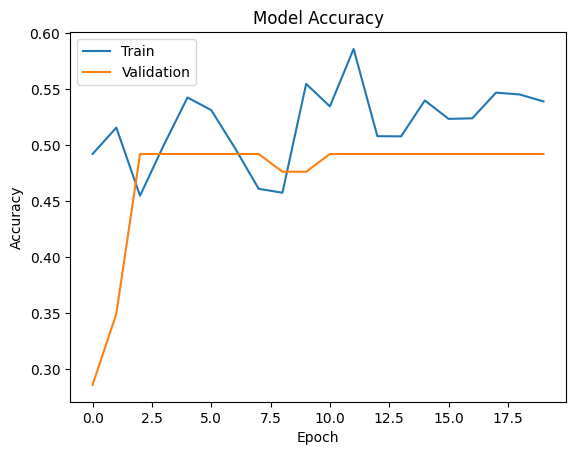

In [60]:
plt.plot(history_vgg16_ffnn_aug.history['accuracy'])
plt.plot(history_vgg16_ffnn_aug.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [61]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)

print("Train performance metrics")
print(model_4_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.492063  0.492063   0.242126  0.324553


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


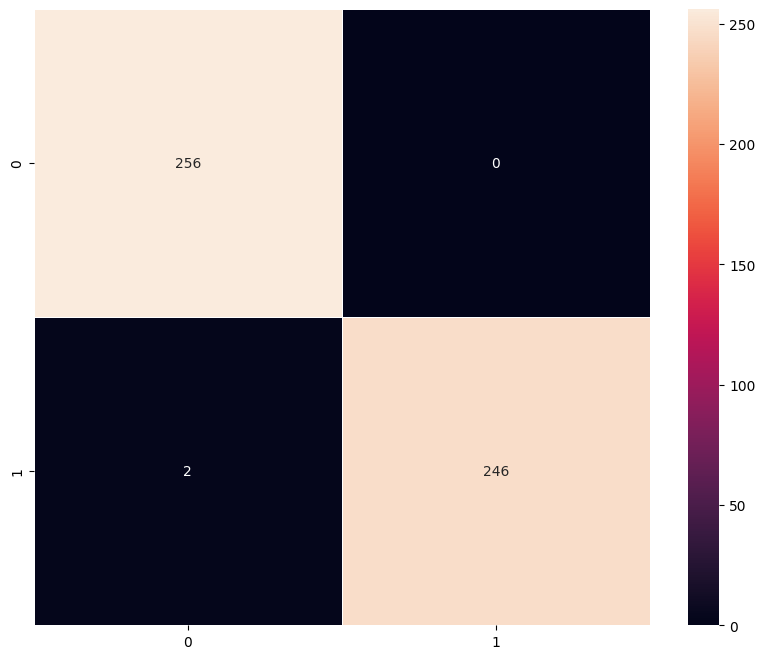

In [62]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

In [63]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.492063  0.492063   0.242126  0.324553


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


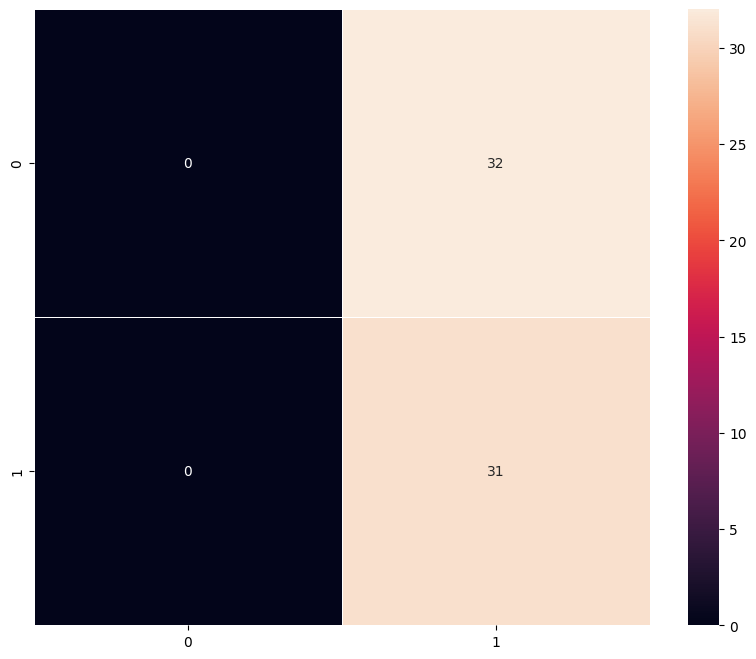

In [64]:
plot_confusion_matrix(model_4,X_val_normalized,y_val)

- The model has achieved approximately 49% of accuracy on both  training set and validation set.

#### Visualizing the prediction:

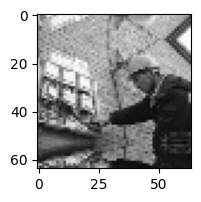

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
Predicted Label :  With Helmet
True Label : With Helmet


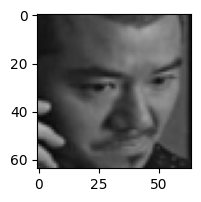

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Label :  With Helmet
True Label : Without Helmet


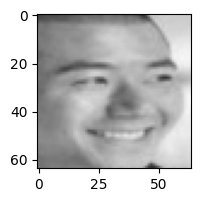

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Label :  With Helmet
True Label : Without Helmet


In [65]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_normalized[1])
plt.show()
pred=model_4.predict(X_val_normalized[1].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[1,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()

pred=model_4.predict(X_val_normalized[33].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[33,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)


plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()

pred=model_4.predict(X_val_normalized[36].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
yhat = "With Helmet" if pred >= 0.5 else "Without Helmet"
y="With Helmet" if y_val.iloc[36,0]==1 else "Without Helmet"

print('Predicted Label : ',yhat)
print('True Label :', y)



# **Model Performance Comparison and Final Model Selection**

In [66]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,

    ],
    axis=1,
)
models_train_comp_df.columns = [
   "CNN Model", "VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [67]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T,

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "CNN Model","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [68]:
models_train_comp_df

,CNN Model,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.847222,0.998016,0.996032,0.492063
Recall,0.847222,0.998016,0.996032,0.492063
Precision,0.882549,0.998024,0.996063,0.242126
F1 Score,0.843170,0.998016,0.996031,0.324553


In [69]:
models_valid_comp_df

,CNN Model,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.841270,1.0,1.0,0.492063
Recall,0.841270,1.0,1.0,0.492063
Precision,0.879063,1.0,1.0,0.242126
F1 Score,0.836732,1.0,1.0,0.324553


In [70]:
models_train_comp_df - models_valid_comp_df

,CNN Model,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.005952,-0.001984,-0.003968,0.0
Recall,0.005952,-0.001984,-0.003968,0.0
Precision,0.003486,-0.001976,-0.003937,0.0
F1 Score,0.006438,-0.001984,-0.003969,0.0


- VGG 16 model(Base) achieves 99% performance accuracy in training and 100% on validation set. Hence signs of overfitting, the possible causes could be
    * The validation set is not truly separate (e.g., same images in train/val).
    * Model memorized training data.
    * No regularization or dropout applied.
    * Data augmentation was NOT used (but even then, 1.0 on val is suspicious).

- VGG16(Base+FFNN) , VGG16(Base+FFNN+Data Aug)  shows almost same performance
- Overfitting Risk is very low for simple CNN model and high for VGG16(Base) and VGG16(Base_FNN)
- VGG16(Base+FFNN+Data Aug) fall in very less accuracy, performs same on both training and validation set.
-  Negative gap = validation score > training score — which is unusual and  
   suggests potential data leakage or evaluation error on models VGG16(Base+FFNN) , VGG16(Base+FFNN).
- VGG16(Base), VGG16(Base+FNN) is not reliable as it potentionally shows overfitting in validation data.
- VGG16(Base+FFNN+Data Aug) is also not reliable because of its poor performance.
- A small gap 0.05 and ~84% accuracy both training and validation set by simple CNN Model shows a healthy generalization, hence we recommend simple CNN Model.


### Test Performance

In [74]:
model_2_test_perf = model_performance_classification(cnn_model, X_test_normalized,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [75]:
model_2_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.875,0.875,0.9,0.873016


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


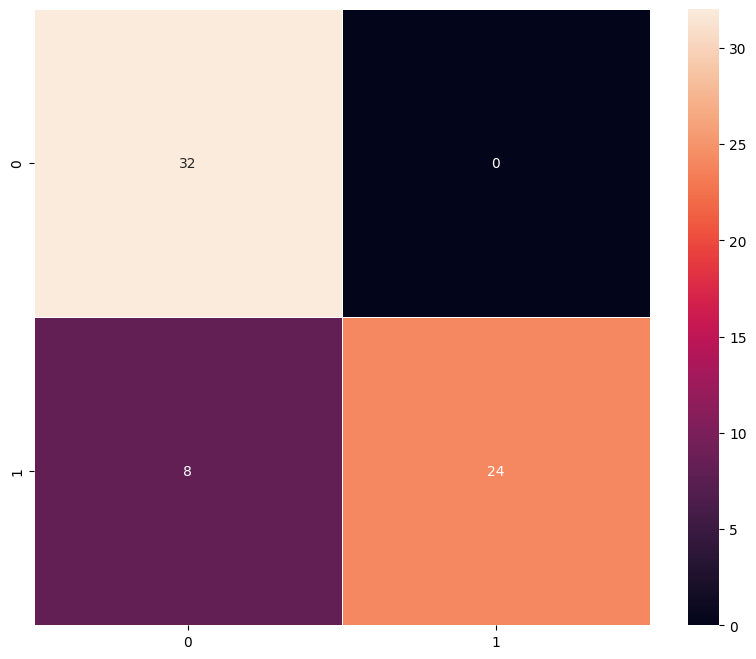

In [77]:
plot_confusion_matrix(cnn_model, X_test_normalized,y_test)

- Simple CNN Model performed well on unseen data, achieved ~87% of accuracy.

# **Actionable Insights & Recommendations**

- Use the simple CNN Model as baseline or production model. It’s simpler, more interpretable, and shows realistic, generalizable performance.
- The CNN Model demonstrates healthy generalization, with only a modest drop from training to validation — indicating it learns patterns rather than memorizing data.
- The VGG-16 variants, despite their near-perfect scores, are not trustworthy. Their perfect validation accuracy strongly suggests data leakage or an invalid train/val split, making them unsuitable for real-world applications.
- Save VGG-16 for research and fix data integrity issues.
    - Validate your data split rigorously
    - Use cross-validation instead of single split
    - Evaluate on a true held-out test set
    

- VGG 16(Base) and VGG 16(Base+FFNN) is not reliable as it potentionally shows overfitting or invalid setup.
-To address overfitting problem,a different data augmentation techniques can be applied as a form of regularization.

- These models can be further improved by training with different filter sizes and different number of filters.

- These models can also be trained on the original image_size i.e 128 x 128 rather than being reduced to 64.

- Data Augmentation can be performed more and dropout_rate can be changed to improve the model performance.

- Other Transfer Learning architectures can also be used to train the CNN model and these models can be used for classification.